In [25]:
#Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Loading the dataset
file_path= "../Data/Loan_acc_prediction_FCS_exercise.xlsx"
loan_df = pd.read_excel(file_path, sheet_name="Loan Demographics")
comm_df = pd.read_excel(file_path, sheet_name="Communication Activity")

In [27]:
# Count Target variable's values
print("Value distribution:")
display(loan_df['Payment_Next30Days'].value_counts())

# Count Target variable's values in percentage
print("\nPercentage of value distribution:") 
display(loan_df['Payment_Next30Days'].value_counts(normalize=True) * 100)

Value distribution:


Payment_Next30Days
0    154220
1       629
Name: count, dtype: int64


Percentage of value distribution:


Payment_Next30Days
0    99.593798
1     0.406202
Name: proportion, dtype: float64

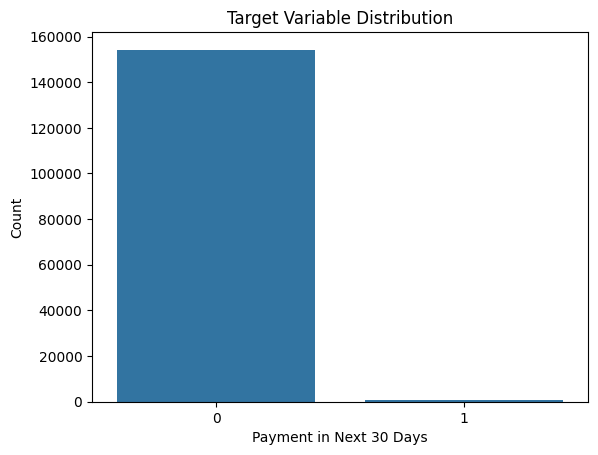

In [28]:
# Visualize Target Distribution
sns.countplot(x='Payment_Next30Days', data=loan_df)

plt.title('Target Variable Distribution')
plt.xlabel('Payment in Next 30 Days')
plt.ylabel('Count')
plt.show()

## Target Variable Observations

- The target variable is extremely imbalanced toward non-payment outcomes
- Approximately 99.59% of observations belong to class `0`
- Only ~0.41% of accounts made payments within the next 30 days
- This indicates a rare-event prediction problem
- Accuracy alone would be misleading for model evaluation
- Metrics such as Precision, Recall, F1-score, and PR-AUC will be more appropriate

In [29]:
# Statistical Summary
loan_df.describe()

,Loan Id,original_balance,current_balance,last_pmt_amt,last_pmt_date,birthday,status,lastNoticeSent,times_dials,times_connect,times_contact,times_rpc,times_ptp,times_up,times_drop,times_lm,total_portal_visit,chargeoff_date,Payment_Next30Days
count,154849.000000,154849.000000,154849.000000,154849.000000,457,154849,154849.000000,154849,154849.000000,154849.000000,154849.000000,154849.000000,154849.000000,154849.000000,154849.000000,154849.000000,154849.000000,154849,154849.000000
mean,89705.369599,2394.808241,2368.725371,1.266741,2025-04-01 12:45:41.356674048,1971-06-01 22:45:18.999799800,25.512222,2024-05-27 18:49:06.741664512,22.640237,1.622962,0.480881,0.039264,0.001279,0.000756,0.141376,0.341668,0.233750,2021-10-21 17:19:38.580423424,0.004062
min,10113.000000,12.010000,-1.140000,0.000000,2022-06-19 00:00:00,1900-01-01 00:00:00,10.000000,1900-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1999-09-20 00:00:00,0.000000
25%,50575.000000,389.310000,385.520000,0.000000,2025-04-11 00:00:00,1964-12-28 00:00:00,10.000000,2025-03-19 00:00:00,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2021-07-31 00:00:00,0.000000
50%,89796.000000,720.010000,706.840000,0.000000,2025-06-14 00:00:00,1978-12-18 00:00:00,17.000000,2025-05-19 00:00:00,17.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022-07-19 00:00:00,0.000000
75%,128903.000000,2844.450000,2775.400000,0.000000,2025-07-28 00:00:00,1989-01-02 00:00:00,36.000000,2025-07-30 00:00:00,31.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023-04-27 00:00:00,0.000000
max,167670.000000,72393.510000,72393.510000,13000.000000,2025-08-31 00:00:00,2024-11-04 00:00:00,89.000000,2025-09-26 00:00:00,166.000000,81.000000,25.000000,12.000000,4.000000,4.000000,37.000000,78.000000,35.000000,2025-05-31 00:00:00,1.000000
std,45178.704206,3602.816449,3579.395777,60.661648,NaN,NaN,20.417604,NaN,21.439572,3.381547,1.187630,0.260689,0.042046,0.033991,0.491671,1.868643,0.852941,NaN,0.063605


## Statistical Summary Observations

- Financial balance features appear heavily right-skewed with significant high-value outliers
- Most customers have no recent payment activity, as reflected by zero-valued `last_pmt_amt`
- `last_pmt_date` is extremely sparse, indicating rare payment behavior
- Several behavioral communication variables appear sparse with many zero values
- Communication intensity varies substantially across accounts
- The `birthday` column contains potentially invalid placeholder values (e.g., customer ages fall outside realistic credit-eligible populations and year 1900 entries)
- Target variable statistics further confirm severe class imbalance

,total_accounts,repayment_rate
status,,
55,41,1.000000
60,178,0.994382
25,27,0.185185
20,10,0.100000
18,2978,0.037609
89,807,0.033457
51,60,0.033333
52,48,0.020833
40,136,0.014706


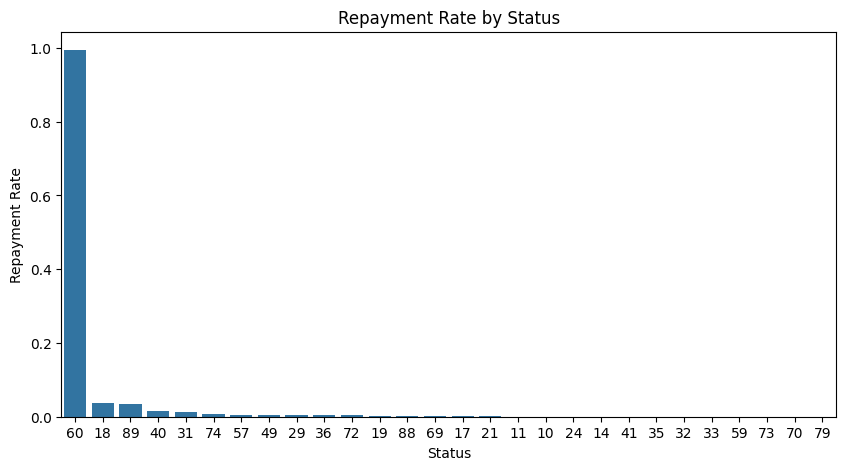

In [30]:
#Categoricsl feature analysis- Status

#Categorical_features = ['state', 'Creditor name', 'status']

status_analysis = (
    
    loan_df.groupby('status')
    .agg(
        total_accounts=('Payment_Next30Days', 'count'),
        repayment_rate=('Payment_Next30Days', 'mean')
    )
    .sort_values(
        by='repayment_rate',
        ascending=False
    )
)

display(status_analysis)



filtered_status = status_analysis[
    status_analysis['total_accounts'] >= 100
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=filtered_status.index.astype(str),
    y=filtered_status['repayment_rate']
)

plt.title('Repayment Rate by Status')
plt.xlabel('Status')
plt.ylabel('Repayment Rate')

plt.show()

,total_accounts,repayment_rate
state,,
VT,228,0.013158
NJ,1940,0.009794
MS,720,0.009722
VA,1643,0.007304
NY,4181,0.007175
ME,566,0.007067
MD,1026,0.006823
WV,611,0.006547
NC,3374,0.006520


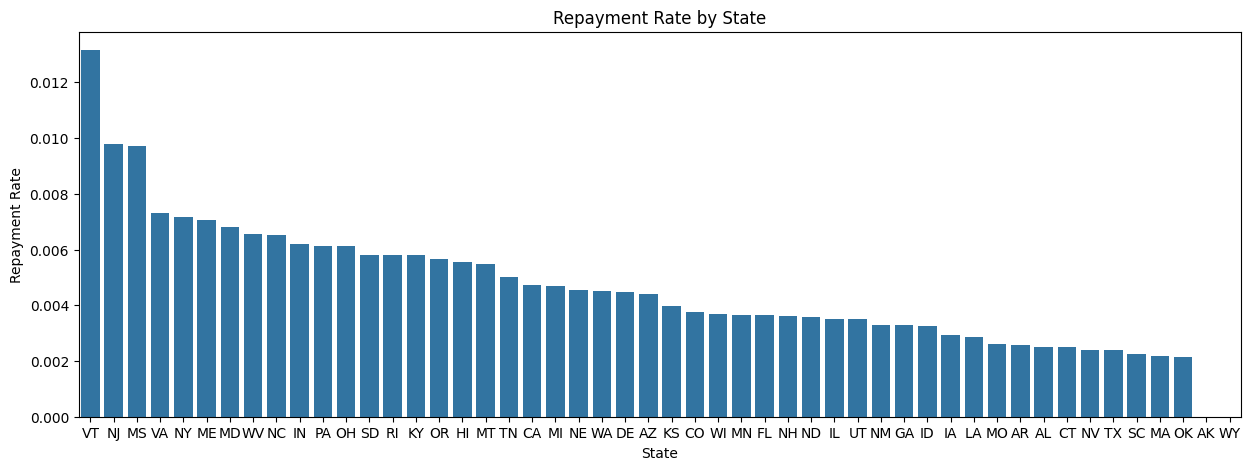

In [31]:
# Categoricsl feature analysis- State

state_analysis = (
    loan_df.groupby('state')
    .agg(
        total_accounts=('Payment_Next30Days', 'count'),
        repayment_rate=('Payment_Next30Days', 'mean')
    )
    .sort_values(
        by='repayment_rate',
        ascending=False
    )
)

display(state_analysis)

filtered_status = state_analysis[
    state_analysis['total_accounts'] >= 100
]

plt.figure(figsize=(15,5))

sns.barplot(
    x=filtered_status.index.astype(str),
    y=filtered_status['repayment_rate']
)

plt.title('Repayment Rate by State')
plt.xlabel('State')
plt.ylabel('Repayment Rate')

plt.show()

,total_accounts,repayment_rate
Creditor name,,
JGG Bank,1,1.000000
SGY Bank,1,1.000000
XYF Bank,1,1.000000
LSY Bank,3,0.666667
BFA Bank,2,0.500000
...,...,...
ZFJ Bank,29,0.000000
ZIQ Bank,5,0.000000
ZQE Bank,8,0.000000


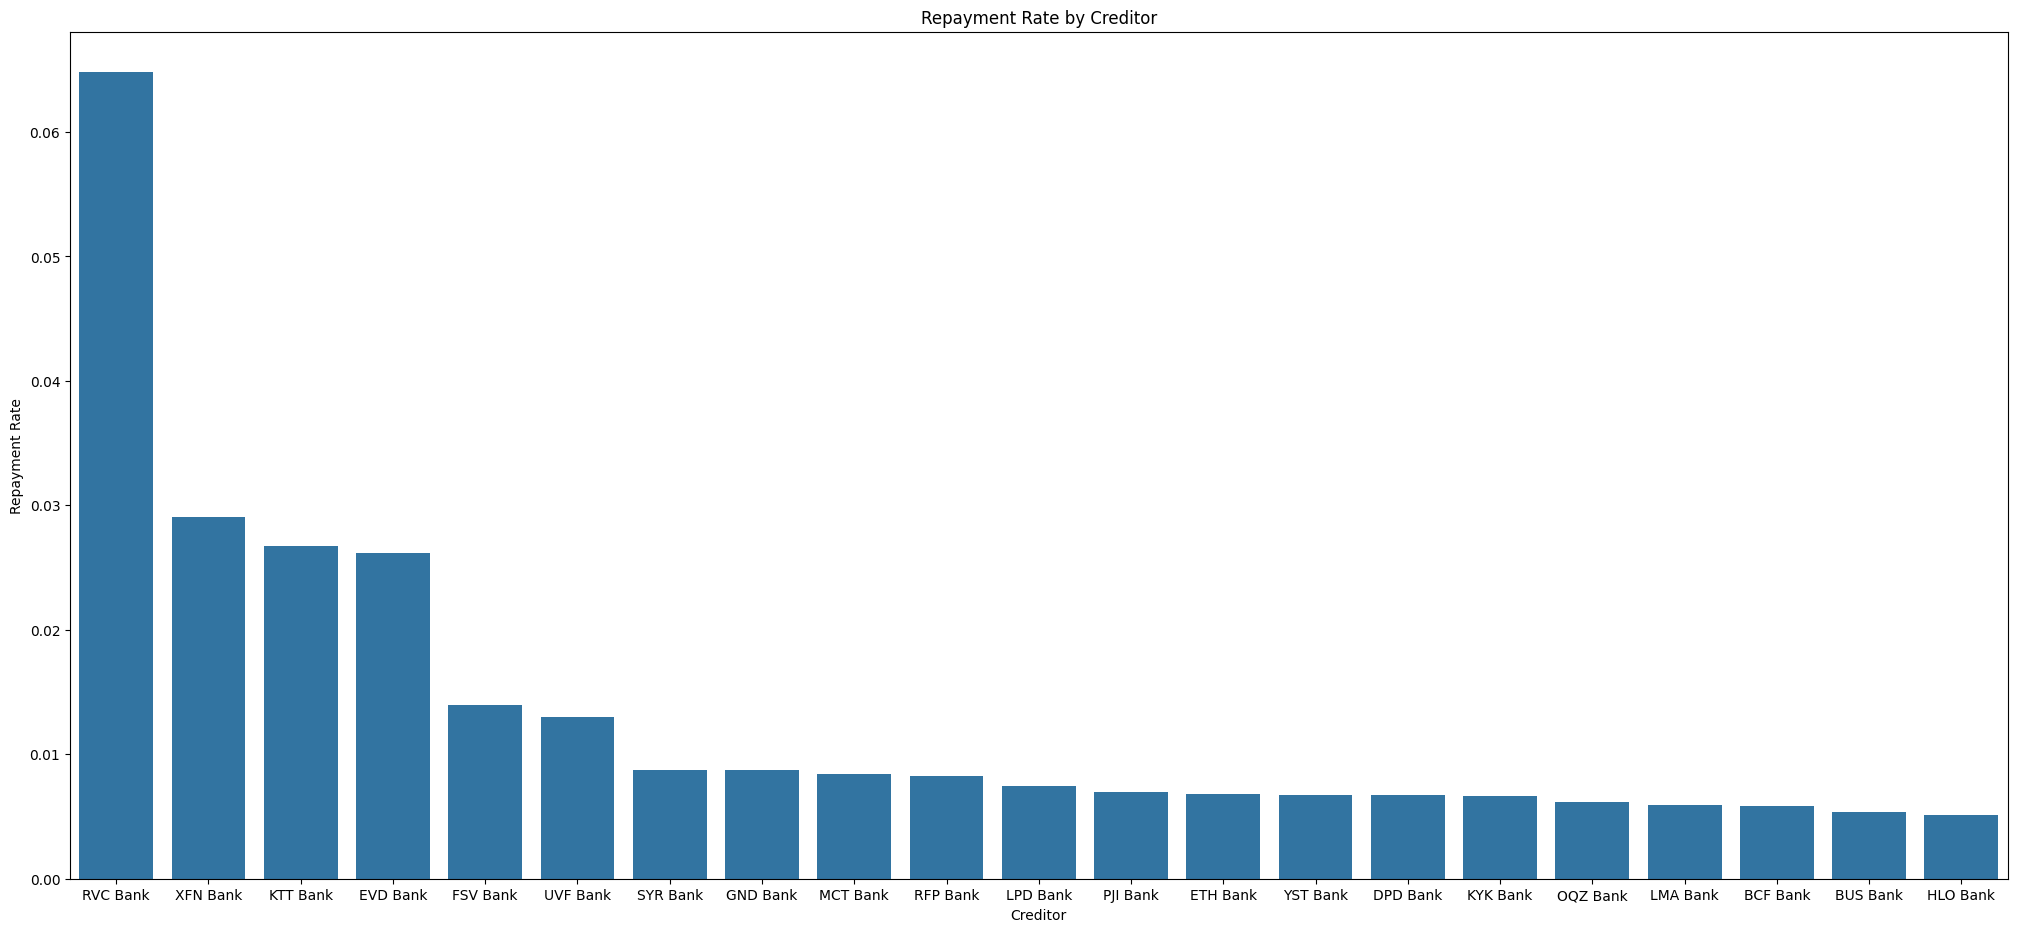

In [32]:
# Categoricsl feature analysis- Creditor

creditor_analysis = (
    loan_df.groupby('Creditor name')
    .agg(
        total_accounts=('Payment_Next30Days', 'count'),
        repayment_rate=('Payment_Next30Days', 'mean')
    )
    .sort_values(
        by='repayment_rate',
        ascending=False
    )
)

display(creditor_analysis)


filtered_status = creditor_analysis[
    (creditor_analysis['total_accounts'] >= 100) &
    (creditor_analysis['repayment_rate'] > 0.005)
]

plt.figure(figsize=(25,11))

sns.barplot(
    x=filtered_status.index.astype(str),
    y=filtered_status['repayment_rate']
)

plt.title('Repayment Rate by Creditor')
plt.xlabel('Creditor')
plt.ylabel('Repayment Rate')

plt.show()

## Categorical Feature Analysis — Key Findings

### 1. State-wise Repayment Behavior
- Repayment rates varied slightly across states.
- Most states showed repayment rates between ~0.2% and ~1.3%.
- Geographic influence appears present but relatively weak.
- State may provide supporting predictive signal when combined with other features.

**Business Insight:**  
Regional economic conditions, regulations, or collection effectiveness may influence repayment behavior.

### 2. Creditor-wise Repayment Behavior
- Significant variation in repayment rates was observed across creditors.
- Some creditors showed substantially higher repayment propensity than others.
- Indicates possible differences in:
  - portfolio quality,
  - borrower risk profile,
  - collection strategies,
  - debt characteristics.

**Business Insight:**  
Creditor identity appears to carry meaningful predictive information and may become an important categorical feature during modeling.

### 3. Status-wise Repayment Behavior
- Account status showed the strongest separation in repayment behavior.
- Certain statuses had much higher repayment rates compared to others.
- Status likely reflects:
  - delinquency stage,
  - account severity,
  - operational segmentation,
  - repayment readiness.

**Business Insight:**  
Status appears to be one of the most predictive categorical variables for the propensity-to-pay model.

## Overall EDA Conclusion
Among categorical variables analyzed:

- `status` → strongest predictive signal
- `Creditor name` → moderate-to-strong predictive signal
- `state` → weak-to-moderate predictive signal

These findings indicate that operational and behavioral account characteristics are more informative than geographic information for repayment prediction.

In [33]:
# Communication Activity Analysis

communication_features = [
    'times_dials',
    'times_connect',
    'times_contact',
    'times_rpc',
    'times_ptp',
    'times_up',
    'times_drop',
    'times_lm',
    'total_portal_visit'
]

communication_analysis = (
    loan_df
    .groupby('Payment_Next30Days')[communication_features]
    .mean()
)

display(communication_analysis)

,times_dials,times_connect,times_contact,times_rpc,times_ptp,times_up,times_drop,times_lm,total_portal_visit
Payment_Next30Days,,,,,,,,,
0,22.662119,1.610083,0.478511,0.037725,0.000558,0.000117,0.141603,0.331507,0.230405
1,17.275040,4.780604,1.062003,0.416534,0.178060,0.157393,0.085851,2.833068,1.054054


## Communication Activity Analysis — Key Findings

Communication behavior showed clear differences between customers who repaid and those who did not repay within the next 30 days.

### Key Behavioral Differences

| Feature | Non-Payers (0) | Payers (1) | Observation |
|---|---|---|---|
| times_dials | 22.66 | 17.28 | Payers required fewer dial attempts |
| times_connect | 1.61 | 4.78 | Payers had significantly more successful connections |
| times_contact | 0.48 | 1.06 | Payers were contacted more frequently |
| times_rpc | 0.04 | 0.42 | Right-party contact was substantially higher among payers |
| times_ptp | 0.0006 | 0.178 | Promise-to-pay activity was much higher among payers |
| times_up | 0.0001 | 0.157 | Positive engagement activity was higher among payers |
| times_drop | 0.142 | 0.086 | Call drops were lower among payers |
| times_lm | 0.33 | 2.83 | Payers received significantly more meaningful interactions/messages |
| total_portal_visit | 0.23 | 1.05 | Payers showed higher portal engagement |

---

## Business Interpretation

Customers who eventually repaid demonstrated:
- stronger engagement,
- higher communication responsiveness,
- more successful contact outcomes,
- higher digital interaction activity.

In contrast, non-payers required:
- more dialing effort,
- but resulted in fewer successful engagements.

---

## Key Modeling Insight

Communication-related features appear highly informative for repayment prediction.

Particularly strong behavioral signals include:
- `times_connect`
- `times_rpc`
- `times_ptp`
- `times_lm`
- `total_portal_visit`

These variables likely capture customer willingness, responsiveness, and repayment intent.

---

## Overall Conclusion

Communication effectiveness appears more important than communication volume.

Successful engagement signals are likely to become strong predictors in the propensity-to-pay model.

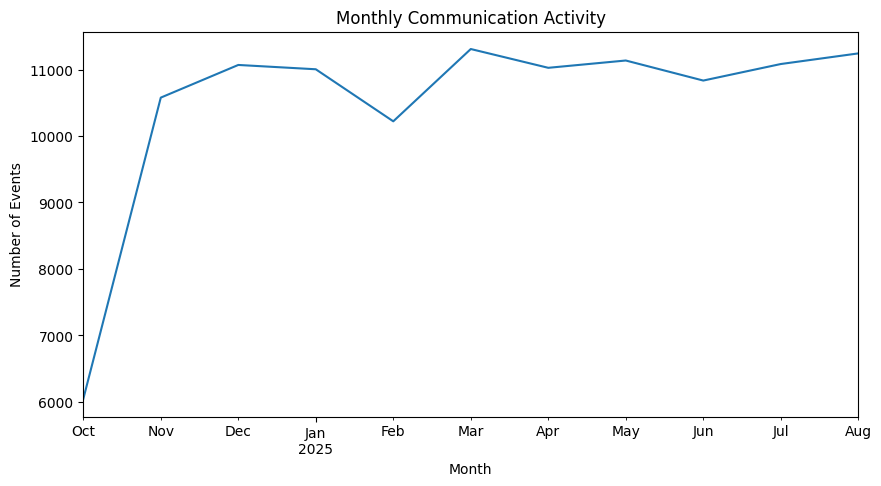

In [34]:
#Temporal Analysis

comm_df['event_month'] = comm_df['Timestamp'].dt.to_period('M')

monthly_events = (
    comm_df['event_month']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

monthly_events.plot(kind='line')

plt.title('Monthly Communication Activity')
plt.xlabel('Month')
plt.ylabel('Number of Events')

plt.show()

## Temporal Analysis Insights

- Monthly communication activity remained relatively stable across the observation period.
- No strong seasonal communication patterns were observed.
- October activity was noticeably lower, likely due to partial-period data availability.
- Stable operational communication behavior increases confidence in using engagement-related features for repayment prediction.

In [35]:
#Bivariate Analysis- Numeric Features vs Target

numeric_features = [
    'current_balance',
    'last_pmt_amt',
    'times_dials',
    'times_connect',
    'times_contact',
    'times_rpc',
    'times_ptp',
    'times_lm',
    'total_portal_visit'
]

# Compare averages by repayment target
numeric_target_analysis = (
    loan_df
    .groupby('Payment_Next30Days')[numeric_features]
    .mean()
    .T
)

display(numeric_target_analysis)


Payment_Next30Days,0,1
current_balance,2371.185138,1765.632576
last_pmt_amt,0.019766,307.003609
times_dials,22.662119,17.275040
times_connect,1.610083,4.780604
times_contact,0.478511,1.062003
times_rpc,0.037725,0.416534
times_ptp,0.000558,0.178060
times_lm,0.331507,2.833068
total_portal_visit,0.230405,1.054054


## Bivariate Analysis Insights

- Successful customer engagement metrics (times_connect, times_contact, times_rpc) were significantly higher among repaying customers.
- Raw collection intensity alone (times_dials) did not correspond to higher repayment likelihood.
- Promise-to-pay interactions showed strong association with repayment behavior.
- Portal engagement and voicemail interaction metrics appeared positively related to repayment propensity.
- Customers with lower current balances demonstrated relatively higher repayment rates.
- Recent payment activity (last_pmt_amt) emerged as one of the strongest behavioral repayment indicators.

Overall, behavioral engagement and repayment activity appeared substantially more predictive than simple operational contact volume.

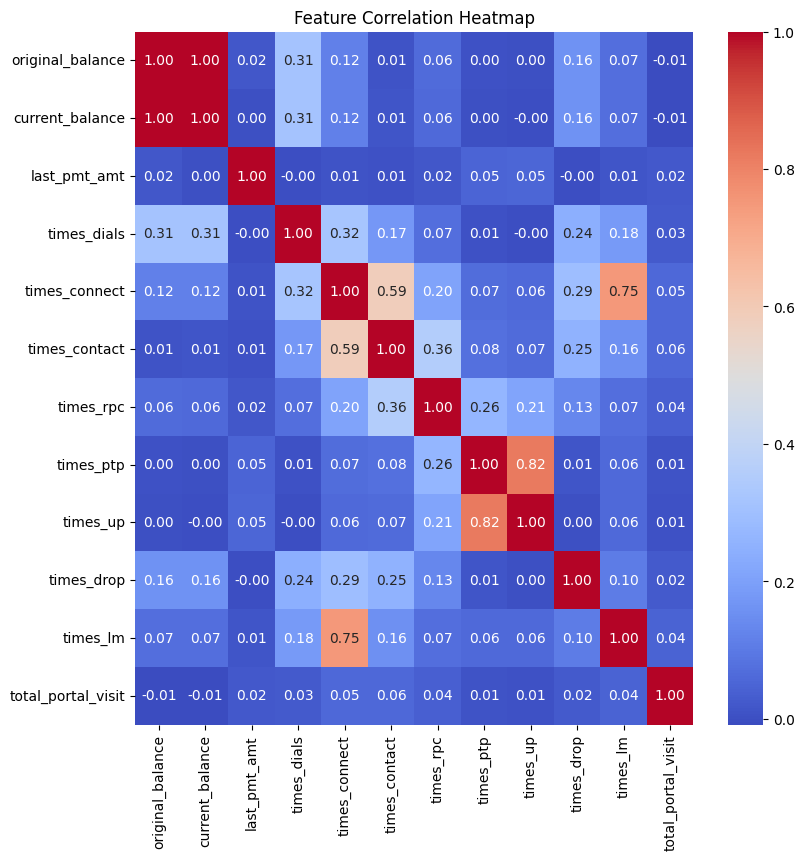

In [36]:
# Correlation analysis

correlation_features = [
    'original_balance',
    'current_balance',
    'last_pmt_amt',
    'times_dials',
    'times_connect',
    'times_contact',
    'times_rpc',
    'times_ptp',
    'times_up',
    'times_drop',
    'times_lm',
    'total_portal_visit'
]

# Compute correlation matrix
corr_matrix = loan_df[correlation_features].corr()

# Plot heatmap
plt.figure(figsize=(9,9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')

plt.show()

The dataset demonstrated generally low-to-moderate feature correlations, suggesting that most variables captured distinct behavioral and operational signals.

A few expected strong correlations were identified:
- original_balance and current_balance were nearly perfectly correlated,
- promise-to-pay and follow-up activity features showed strong association,
- communication engagement metrics displayed moderate relationships.

Overall, the dataset exhibited relatively low redundancy and strong behavioral feature diversity, which is favorable for tree-based predictive modeling.